### test hypergeometric

In [58]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [59]:
import sys
sys.path.append("/home/izirdeli/Documents.cglab/DownStreamAnalysis/03.Code")
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

# DATA

In [60]:
data = pd.read_csv("../../Model/Data_Preparation/processed/m2or_pairs_model.csv", sep=",")
data

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


In [61]:
predictions = pd.read_csv("../../Downstream_Analysis/predictions/aggregated/ASR_Predictions/asr_median_prediction_wide.csv")
predictions

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,node_100_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,node_101_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,node_102_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,node_103_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,node_104_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,node_96_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
428,node_97_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
429,node_98_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
430,node_99_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [62]:
smiles_map = (
    data[["smiles_id", "SMILES"]]
    .drop_duplicates()
    .rename(columns={"smiles_id": "SML_ID"})
)

In [63]:
smiles_map

,SML_ID,SMILES
0,SML0000,CC1=CC[C@H](CC1)C(=C)C
1,SML0001,CC1=CC[C@@H](CC1=O)C(=C)C
2,SML0002,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C
3,SML0003,CCCCO
4,SML0004,CCCCOCC(C)O
...,...,...
48316,SML0749,CCOC(=O)C(C)S
49585,SML0750,CC(=O)C1=CC2=CC=CC=C2C=C1
50146,SML0768,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C
50251,SML0769,C=CCSS(=O)CC=C


In [64]:
nodes_of_interest = ["node_1_ASR", "node_2_ASR", "node_3_ASR"]

pred_sub = predictions[predictions["protein_id"].isin(nodes_of_interest)].copy()
pred_sub

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
110,node_1_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
221,node_2_ASR,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
332,node_3_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [65]:
sml_cols = [c for c in pred_sub.columns if c != "protein_id"]

# long format
pred_long = pred_sub.melt(
    id_vars="protein_id",
    value_vars=sml_cols,
    var_name="SML_ID",
    value_name="active"
)

pred_long

,protein_id,SML_ID,active
0,node_1_ASR,SML0000,0
1,node_2_ASR,SML0000,0
2,node_3_ASR,SML0000,0
3,node_1_ASR,SML0001,0
4,node_2_ASR,SML0001,0
...,...,...,...
2257,node_2_ASR,SML0769,0
2258,node_3_ASR,SML0769,0
2259,node_1_ASR,SML0770,0
2260,node_2_ASR,SML0770,0


In [66]:
pred_active = pred_long[pred_long["active"] == 1].copy()
pred_active = pred_active.merge(smiles_map, on="SML_ID", how="left")

pred_active

,protein_id,SML_ID,active,SMILES
0,node_1_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
1,node_3_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
2,node_1_ASR,SML0014,1,CC1(C2CCC(=C)C1C2)C
3,node_2_ASR,SML0015,1,CC(=O)O
4,node_2_ASR,SML0016,1,CCCC(=O)O
...,...,...,...,...
415,node_1_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
416,node_3_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
417,node_1_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC
418,node_3_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC


In [67]:
node_counts = (
    pred_active.groupby("protein_id")["SMILES"]
    .nunique()
    .reset_index(name="n_unique_ligands")
)

node_counts

,protein_id,n_unique_ligands
0,node_1_ASR,177
1,node_2_ASR,130
2,node_3_ASR,113


In [68]:
node_ligands = (
    pred_active.groupby("protein_id")["SMILES"]
    .apply(list)
    .to_dict()
)

for node, ligs in node_ligands.items():
    print(f"\n{node}: {len(ligs)} ligands")
    print(ligs)


node_1_ASR: 177 ligands
['CC1=CCC2CC1C2(C)C', 'CC1(C2CCC(=C)C1C2)C', 'C1=CC=C2C(=C1)C=CC(=O)O2', 'CC(=CCC/C(=C/CC/C(=C/CO)/C)/C)C', 'CC(=CCC/C(=C/CO)/C)C', 'CC(CC1=CC=C(C=C1)C(C)(C)C)C=O', 'CC(=O)NCCC1=CNC2=C1C=C(C=C2)OC', 'CC1CCC2=NC=CN=C12', 'CC(=O)C1=NC=CN=C1', 'CCC(C)C1=NC=CN=C1OC', 'CC(CC=O)C1=CC=CC=C1', 'CC(=CCC/C(=C\\CO)/C)C', 'CCCCCOC(=O)C', 'C1CCC(=O)CC1', 'CC(=O)C1=CC=CC=C1', 'CC1C(=NC(S1)C)C', 'C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C', 'CCCCCCC/C=C/C=O', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@@]3(CCC(=O)C4)C', 'CCCCOC(=O)C', 'C1CCCCCC(=O)OCCOC(=O)CCCCC1', 'CC(=O)OC1=C(C=C(C=C1)CC=C)OC', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)CC[C@]34C', 'CC(=CCC/C(=C/COC(=O)C)/C)C', 'CC(=O)O[C@H]1C[C@H]2CC[C@]1(C2(C)C)C', 'C/C=C/C1=CC(=C(C=C1)O)OC', 'C1=CC=C(C=C1)CC=O', 'COC(=O)C1=CC=CC=C1', 'CC1=C(C=C(C=C1)[N+](=O)[O-])[N+](=O)[O-]', 'CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C', 'CC(C)C1=NC=CN=C1OC', 'CC(C)CC1=NC=CN=C1OC', 'CCCCCC/C=C/C=O', 'C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)

In [69]:
node_presence = (
    pred_active.assign(active=1)
    .pivot_table(
        index="SMILES",
        columns="protein_id",
        values="active",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

node_presence = node_presence.rename(columns={
    "node_1_ASR": "common_ancestor",
    "node_2_ASR": "class1_ancestor",
    "node_3_ASR": "class2_ancestor"
})

node_presence

protein_id,SMILES,common_ancestor,class1_ancestor,class2_ancestor
0,C(C(=O)C(=O)O)O,0,1,0
1,C(C(=O)O)N,0,1,0
2,C(C(=O)O)S,0,1,0
3,C(C(C(=O)O)N)N,0,1,0
4,C(C(C=O)O)O,0,1,0
...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,1,1,1
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,1,1,1


# ACTIVATION PATTERN

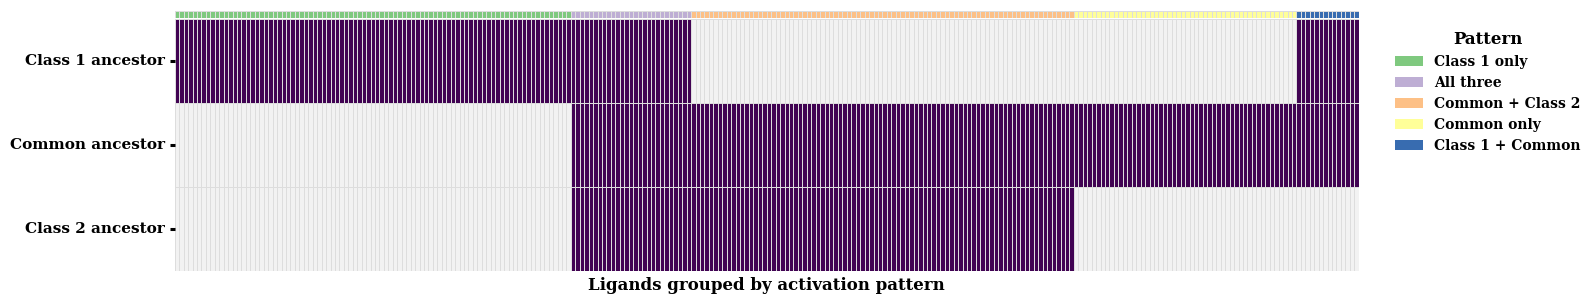

In [70]:
# build matrix from node_presence
X = (
    node_presence.set_index("SMILES")[["class1_ancestor", "common_ancestor", "class2_ancestor"]]
    .T
)

# rename rows for display
X.index = ["Class 1 ancestor", "Common ancestor", "Class 2 ancestor"]

# keep only ligands active in at least one node
X = X.loc[:, X.sum(axis=0) > 0]

# pattern per ligand (column), based on row order above
patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)

# readable order
pat_order = ["100", "111", "011", "010", "110"]

# sort columns by pattern
col_order = sorted(X.columns, key=lambda c: pat_order.index(patterns.loc[c]))
Xo = X[col_order]

# color strip for column patterns
pat_palette = dict(zip(pat_order, sns.color_palette("Accent", n_colors=len(pat_order))))
col_colors = patterns.loc[col_order].map(pat_palette).tolist()

# binary heatmap colors
bin_cmap = ListedColormap(["#f2f2f2", "#410353"])

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=bin_cmap,
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4,
    linecolor="#dddddd",
    figsize=(14, 3.2),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03)
)

# format heatmap axis
ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")

pattern_labels = {
    "100": "Class 1 only",
    "111": "All three",
    "011": "Common + Class 2",
    "010": "Common only",
    "110": "Class 1 + Common"
}

handles = [
    Patch(facecolor=pat_palette[p], edgecolor='none', label=pattern_labels[p])
    for p in pat_order
]


ax.legend(
    handles=handles,
    title="Pattern",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
#plt.savefig("logp_transitions_human_ancestors_heatmap.svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

In [71]:
pattern_df = pd.DataFrame({
    "SMILES": X.columns,
    "pattern": patterns.loc[X.columns].values
})

pattern_df

,SMILES,pattern
0,C(C(=O)C(=O)O)O,100
1,C(C(=O)O)N,100
2,C(C(=O)O)S,100
3,C(C(C(=O)O)N)N,100
4,C(C(C=O)O)O,100
...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111


In [72]:
pattern_sets = {
    pat: set(pattern_df.loc[pattern_df["pattern"] == pat, "SMILES"])
    for pat in ["100", "111", "011", "010", "110"]
}

class1_side_a_e = pattern_sets["100"] | pattern_sets["110"]
class2_side_c = pattern_sets["011"]
shared_code_b = pattern_sets["111"]
common_ancestor_only_d = pattern_sets["010"]

code_sets = {
    "class1_side_a_e": class1_side_a_e,
    "class2_side_c": class2_side_c,
    "shared_code_b": shared_code_b,
    "common_ancestor_only_d": common_ancestor_only_d,
}

for code, ligs in code_sets.items():
    print(f"{code}: {len(ligs)} ligands")

class1_side_a_e: 103 ligands
class2_side_c: 86 ligands
shared_code_b: 27 ligands
common_ancestor_only_d: 50 ligands


In [73]:
all_smiles = sorted(set(pattern_df["SMILES"]))
print(len(all_smiles))

desc_rows = []
for smi in all_smiles:
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        desc_rows.append({
            "SMILES": smi,
            "logP": np.nan,
            "TPSA": np.nan,
            "MW": np.nan,
            "HBD": np.nan,
            "HBA": np.nan
        })
    else:
        desc_rows.append({
            "SMILES": smi,
            "logP": Descriptors.MolLogP(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "MW": Descriptors.MolWt(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol)
        })

desc_df = pd.DataFrame(desc_rows)

pattern_analysis_df = pattern_df.merge(desc_df, on="SMILES", how="left")
pattern_analysis_df

266


,SMILES,pattern,logP,TPSA,MW,HBD,HBA
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3
...,...,...,...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111,3.0598,54.37,302.414,1,3
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.4891,37.30,274.404,1,2
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.8792,37.30,288.431,1,2
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111,3.8792,37.30,288.431,1,2


In [74]:
fg_smarts = {
    "carboxylic_acid": "[CX3](=O)[OX2H1]",
    "alcohol": "[OX2H][CX4;!$(C=O)]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "ester": "[CX3](=O)[OX2][#6]",
    "ether": "[OD2]([#6])[#6]",
    "amine": "[NX3;H2,H1,H0;!$(NC=O)]",
    "amide": "[NX3][CX3](=O)[#6]",
    "aromatic_ring": "a1aaaaa1",
    "phenol": "c[OX2H]",
    "nitrile": "[CX2]#N",
    "alkene": "[CX3]=[CX3]"
}

fg_patterns = {name: Chem.MolFromSmarts(smarts) for name, smarts in fg_smarts.items()}

# parse molecules once
mol_map = {smi: Chem.MolFromSmiles(smi) for smi in all_smiles}

fg_rows = []
for smi in all_smiles:
    mol = mol_map[smi]
    row = {"SMILES": smi}
    for fg_name, patt in fg_patterns.items():
        row[fg_name] = int(mol.HasSubstructMatch(patt)) if mol is not None else np.nan
    fg_rows.append(row)

fg_df = pd.DataFrame(fg_rows)

pattern_analysis_df = pattern_analysis_df.merge(fg_df, on="SMILES", how="left")
pattern_analysis_df

,SMILES,pattern,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3,1,1,0,1,0,0,0,0,0,0,0,0
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2,1,0,0,0,0,0,1,0,0,0,0,0
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2,1,0,0,0,0,0,0,0,0,0,0,0
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3,1,0,0,0,0,0,1,0,0,0,0,0
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3,0,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111,3.0598,54.37,302.414,1,3,0,1,0,1,0,0,0,0,0,0,0,1
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.4891,37.30,274.404,1,2,0,1,0,1,0,0,0,0,0,0,0,1
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1


In [75]:
fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol",
    "nitrile", "alkene"
]

desc_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]

pattern_analysis_df = (
    pattern_df
    .merge(desc_df, on="SMILES", how="left")
    .merge(fg_df, on="SMILES", how="left")
    .copy()
)

observed_patterns = ["100", "111", "011", "010", "110"]
pattern_analysis_df = pattern_analysis_df[
    pattern_analysis_df["pattern"].isin(observed_patterns)
].copy()

# broader biological grouping
def assign_pattern_group(p):
    if p in ["100", "110"]:
        return "class1_side"
    elif p == "111":
        return "combinatorial_111"
    elif p == "011":
        return "class2_side"
    else:
        return "common_ancestor_d"

pattern_analysis_df["pattern_group"] = pattern_analysis_df["pattern"].apply(assign_pattern_group)

pattern_analysis_df

,SMILES,pattern,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene,pattern_group
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3,1,1,0,1,0,0,0,0,0,0,0,0,class1_side
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2,1,0,0,0,0,0,1,0,0,0,0,0,class1_side
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2,1,0,0,0,0,0,0,0,0,0,0,0,class1_side
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3,1,0,0,0,0,0,1,0,0,0,0,0,class1_side
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3,0,1,1,0,0,0,0,0,0,0,0,0,class1_side
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111,3.0598,54.37,302.414,1,3,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.4891,37.30,274.404,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111


## CLASS I (a+e) VS CLASS II (c)

In [76]:
ae_c = pattern_analysis_df[
    pattern_analysis_df["pattern"].isin(["100", "110", "011"])
].copy()

ae_c["comparison_group"] = ae_c["pattern"].apply(
    lambda p: "class1_side" if p in ["100", "110"] else "class2_side"
)

ae_c["comparison_group"].value_counts()

comparison_group
class1_side    103
class2_side     86
Name: count, dtype: int64

In [77]:
ae_c

,SMILES,pattern,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,...,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene,pattern_group,comparison_group
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3,1,1,0,...,0,0,0,0,0,0,0,0,class1_side,class1_side
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2,1,0,0,...,0,0,1,0,0,0,0,0,class1_side,class1_side
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2,1,0,0,...,0,0,0,0,0,0,0,0,class1_side,class1_side
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3,1,0,0,...,0,0,1,0,0,0,0,0,class1_side,class1_side
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3,0,1,1,...,0,0,0,0,0,0,0,0,class1_side,class1_side
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,C[C@@H]1CCO[C@H](C1)C=C(C)C,011,2.7677,9.23,154.253,0,1,0,0,0,...,0,1,0,0,0,0,0,1,class2_side,class2_side
253,C[C@@]12CC[C@@H](C1(C)C)CC2=O,011,2.4017,17.07,152.237,0,1,0,0,0,...,0,0,0,0,0,0,0,0,class2_side,class2_side
254,C[C@H](C(=O)N[C@H](C)C(=O)O)N,100,-1.0771,92.42,160.173,3,3,1,0,0,...,0,0,1,1,0,0,0,0,class1_side,class1_side
255,C[C@H]1CC(C2=C(C1(C)C)C[C@@]3([C@H](C2)O3)C)(C)C,011,4.3265,12.53,234.383,0,1,0,0,0,...,0,1,0,0,0,0,0,1,class2_side,class2_side


In [78]:
desc_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]

summary_table = (
    ae_c.groupby("comparison_group")[desc_cols]
    .agg(["count", "median", "mean"])
)

summary_table

logP                    TPSA                      MW  \
                 count  median      mean count median       mean count   
comparison_group                                                         
class1_side        103  1.8822  1.732603   103  37.30  48.272524   103   
class2_side         86  2.4017  2.558453    86  17.07  21.420814    86   

                                        HBD                    HBA         \
                   median        mean count median      mean count median   
comparison_group                                                            
class1_side       158.241  168.014117   103    1.0  1.223301   103    1.0   
class2_side       150.221  162.756267    86    0.0  0.162791    86    1.0   

                            
                      mean  
comparison_group            
class1_side       1.834951  
class2_side       1.476744

In [79]:
from scipy.stats import mannwhitneyu

def mw_test(
    df,
    value_col,
    alternative="two-sided",
    group_col="comparison_group",
    group_labels=("class1_side", "class2_side"),
):
    x = df.loc[df[group_col] == group_labels[0], value_col].dropna().values
    y = df.loc[df[group_col] == group_labels[1], value_col].dropna().values

    if len(x) == 0 or len(y) == 0:
        raise ValueError(f"One or both groups are empty for '{value_col}'")

    stat, p = mannwhitneyu(x, y, alternative=alternative)

    n = len(x) * len(y)
    r = 1 - (2 * stat) / n  # rank-biserial correlation [-1, 1]

    return {
        "descriptor": value_col,
        "n_class1": len(x),
        "n_class2": len(y),
        "median_class1": np.median(x),
        "median_class2": np.median(y),
        "U_stat": stat,
        "p_value": p,
        "effect_size_r": r,
    }


tests = [
    ("logP", "less"),
    ("TPSA", "greater"),
    ("HBD",  "greater"),
    ("HBA",  "greater"),
    ("MW",   "two-sided"),
]

descriptor_stats = pd.DataFrame([
    mw_test(ae_c, col, alternative=alt) for col, alt in tests
])

descriptor_stats

,descriptor,n_class1,n_class2,median_class1,median_class2,U_stat,p_value,effect_size_r
0,logP,103,86,1.8822,2.4017,3115.5,2.274013e-04,0.296568
1,TPSA,103,86,37.3000,17.0700,7569.5,9.519053e-18,-0.709077
2,HBD,103,86,1.0000,0.0000,7157.0,4.955841e-16,-0.615940
3,HBA,103,86,1.0000,1.0000,5057.5,3.216798e-02,-0.141906
4,MW,103,86,158.2410,150.2210,4534.5,7.791855e-01,-0.023820


In [80]:
C1_COLOR = "#4f0205"   
C2_COLOR = "#f2b494"   
SIG_COLOR = "#2ecc71"
NS_COLOR  = "#95a5a6"

descriptors = ["logP", "TPSA", "HBD", "HBA", "MW"]

tests = [
    ("logP", "less"),
    ("TPSA", "greater"),
    ("HBD",  "greater"),
    ("HBA",  "greater"),
    ("MW",   "two-sided"),
]

def mw_test(df, value_col, alternative="two-sided",
            group_col="comparison_group",
            group_labels=("class1_side", "class2_side")):
    x = df.loc[df[group_col] == group_labels[0], value_col].dropna().values
    y = df.loc[df[group_col] == group_labels[1], value_col].dropna().values
    if len(x) == 0 or len(y) == 0:
        raise ValueError(f"One or both groups are empty for '{value_col}'")
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    r = 1 - (2 * stat) / (len(x) * len(y))
    return {"descriptor": value_col, "n_class1": len(x), "n_class2": len(y),
            "median_class1": np.median(x), "median_class2": np.median(y),
            "U_stat": stat, "p_value": p, "effect_size_r": r}

stats_df = pd.DataFrame([mw_test(ae_c, col, alternative=alt) for col, alt in tests])
stats_df

,descriptor,n_class1,n_class2,median_class1,median_class2,U_stat,p_value,effect_size_r
0,logP,103,86,1.8822,2.4017,3115.5,2.274013e-04,0.296568
1,TPSA,103,86,37.3000,17.0700,7569.5,9.519053e-18,-0.709077
2,HBD,103,86,1.0000,0.0000,7157.0,4.955841e-16,-0.615940
3,HBA,103,86,1.0000,1.0000,5057.5,3.216798e-02,-0.141906
4,MW,103,86,158.2410,150.2210,4534.5,7.791855e-01,-0.023820


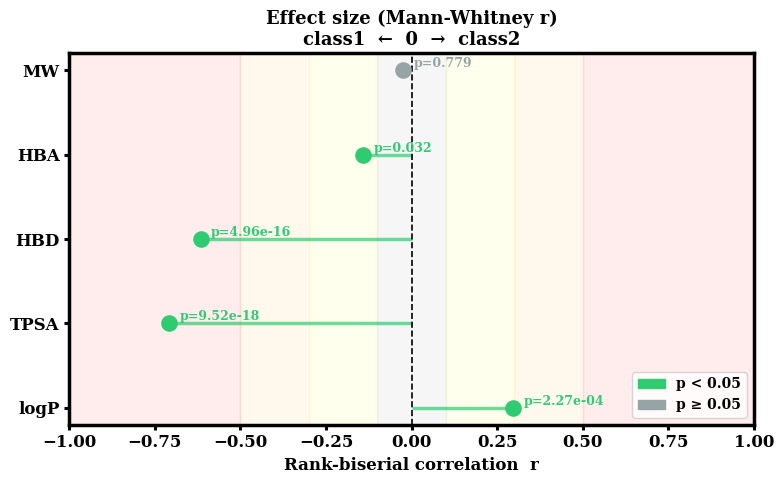

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, row in stats_df.iterrows():
    sig   = row["p_value"] < 0.05
    color = SIG_COLOR if sig else NS_COLOR
    r     = row["effect_size_r"]

    # simple bootstrap CI for r (via U)
    ax.scatter(r, i, color=color, s=120, zorder=3)
    ax.hlines(i, 0, r, colors=color, linewidth=2.5, alpha=0.7)

ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.axvspan(-0.1, 0.1, alpha=0.07, color="gray", label="Negligible (|r|<0.1)")
ax.axvspan( 0.1, 0.3, alpha=0.07, color="yellow")
ax.axvspan(-0.3,-0.1, alpha=0.07, color="yellow")
ax.axvspan( 0.3, 0.5, alpha=0.07, color="orange")
ax.axvspan(-0.5,-0.3, alpha=0.07, color="orange")
ax.axvspan( 0.5, 1.1, alpha=0.07, color="red")
ax.axvspan(-1.1,-0.5, alpha=0.07, color="red")

ax.set_yticks(range(len(stats_df)))
ax.set_yticklabels(stats_df["descriptor"], fontsize=12)
ax.set_xlabel("Rank-biserial correlation  r", fontsize=12)
ax.set_title("Effect size (Mann-Whitney r)\nclass1  ←  0  →  class2", fontsize=13)
ax.set_xlim(-1, 1)

# annotate p-values
for i, row in stats_df.iterrows():
    p_label = f"p={row['p_value']:.2e}" if row['p_value'] < 0.001 else f"p={row['p_value']:.3f}"
    ax.text(row["effect_size_r"] + 0.03, i, p_label, va="bottom", fontsize=9,
            color=SIG_COLOR if row["p_value"] < 0.05 else NS_COLOR)

sig_patch = mpatches.Patch(color=SIG_COLOR, label="p < 0.05")
ns_patch  = mpatches.Patch(color=NS_COLOR,  label="p ≥ 0.05")
ax.legend(handles=[sig_patch, ns_patch], loc="lower right")
plt.tight_layout()
#plt.savefig("plot1_forest.png", dpi=150)
plt.show()

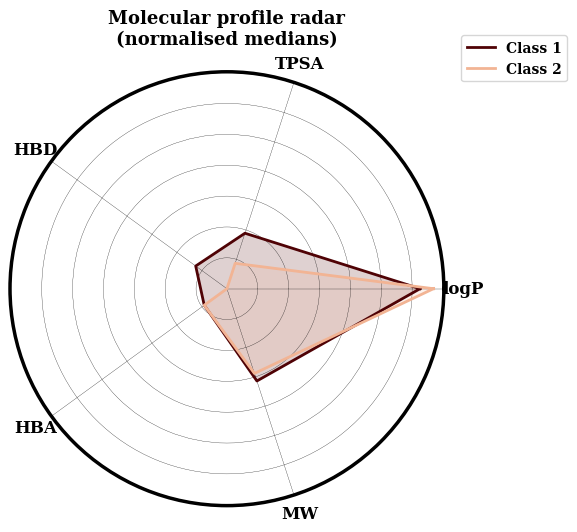

In [82]:
from matplotlib.patches import FancyArrowPatch

categories = descriptors
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Normalise medians to [0,1] per descriptor for comparability
norm_vals = {}
for col in descriptors:
    all_vals = ae_c[col].dropna()
    vmin, vmax = all_vals.min(), all_vals.max()
    for grp in ["class1_side", "class2_side"]:
        med = ae_c.loc[ae_c["comparison_group"] == grp, col].median()
        norm_vals[(grp, col)] = (med - vmin) / (vmax - vmin) if vmax > vmin else 0.5

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for grp, color, label in [("class1_side", C1_COLOR, "Class 1"),
                           ("class2_side", C2_COLOR, "Class 2")]:
    values = [norm_vals[(grp, c)] for c in categories] 
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=label)
    ax.fill(angles, values, color=color, alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels([])
ax.set_title("Molecular profile radar\n(normalised medians)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
#plt.savefig("plot3_radar.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

/tmp/ipykernel_3805385/4265431907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ae_c, x="comparison_group", y=col,
/tmp/ipykernel_3805385/4265431907.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["class1", "class2"], fontsize=9)
/tmp/ipykernel_3805385/4265431907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ae_c, x="comparison_group", y=col,
/tmp/ipykernel_3805385/4265431907.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["class1", "class2"], fontsize

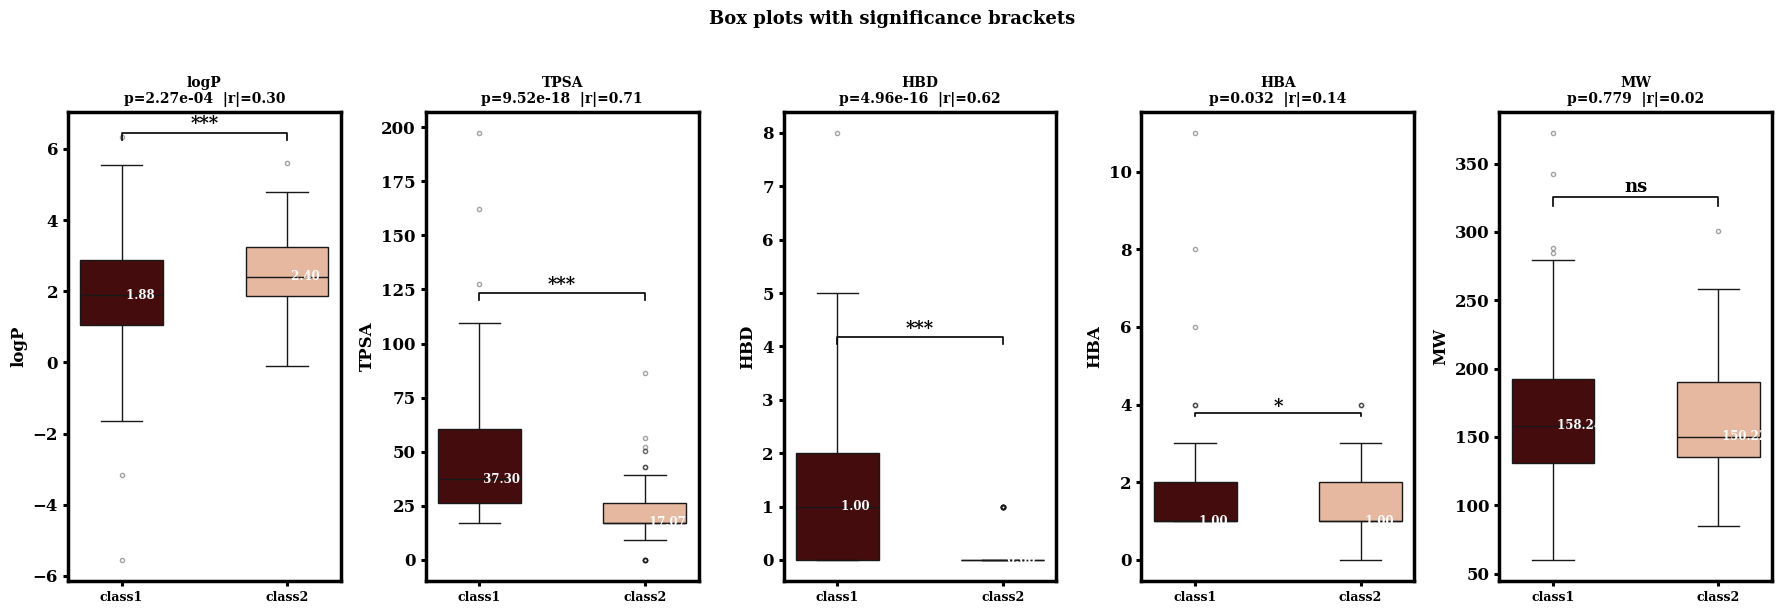

In [83]:
palette = {
    "class1_side": "#4f0205",
    "class2_side": "#f2b494",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for ax, (col, alt) in zip(axes, tests):
    row = stats_df[stats_df["descriptor"] == col].iloc[0]

    sns.boxplot(data=ae_c, x="comparison_group", y=col,
                palette=palette, ax=ax, width=0.5,
                flierprops=dict(marker="o", markersize=3, alpha=0.4))

    # median labels
    for j, grp in enumerate(["class1_side", "class2_side"]):
        med = ae_c.loc[ae_c["comparison_group"] == grp, col].median()
        ax.text(j, med, f" {med:.2f}", va="center", fontsize=8.5,
                color="white", fontweight="bold")

    # significance bracket
    y_max   = ae_c[col].quantile(0.95)
    y_range = ae_c[col].quantile(0.95) - ae_c[col].quantile(0.05)
    y_top   = y_max + y_range * 0.35
    p       = row["p_value"]
    stars   = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ax.plot([0, 0, 1, 1], [y_top, y_top + y_range*0.04, y_top + y_range*0.04, y_top],
            lw=1.2, color="black")
    ax.text(0.5, y_top + y_range * 0.06, stars, ha="center", fontsize=13)

    p_label = f"p={p:.2e}" if p < 0.001 else f"p={p:.3f}"
    ax.set_title(f"{col}\n{p_label}  |r|={abs(row['effect_size_r']):.2f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["class1", "class2"], fontsize=9)

plt.suptitle("Box plots with significance brackets", fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig("plot4_boxplots.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [84]:
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# config 
FG_COLS = [
    "carboxylic_acid", "alcohol", "aldehyde", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol", "nitrile", "alkene"
]
FG_LABELS = [c.replace("_", " ").title() for c in FG_COLS]

C1_COLOR = "#4f0205"   
C2_COLOR = "#f2b494"   
PALETTE   = {"class1_side": C1_COLOR, "class2_side": C2_COLOR}

GROUPS    = ["class1_side", "class2_side"]
GROUP_LABELS = {"class1_side": "Class 1", "class2_side": "Class 2"}

# statistical tests per functional group 
def fg_stats(df):
    rows = []
    for col in FG_COLS:
        ct = pd.crosstab(df["comparison_group"], df[col])
        # ensure both 0/1 columns exist
        for v in [0, 1]:
            if v not in ct.columns:
                ct[v] = 0
        ct = ct[[0, 1]]

        # fisher exact if small counts, else chi2
        if ct.values.min() < 5:
            odds, p = fisher_exact(ct.values)
        else:
            chi2, p, _, _ = chi2_contingency(ct.values)

        prev = {}
        for grp in GROUPS:
            sub = df.loc[df["comparison_group"] == grp, col]
            prev[grp] = sub.mean() * 100   # percentage

        rows.append({
            "fg": col,
            "label": col.replace("_", " ").title(),
            "prev_c1": prev["class1_side"],
            "prev_c2": prev["class2_side"],
            "diff":    prev["class1_side"] - prev["class2_side"],
            "p_raw":   p,
        })

    res = pd.DataFrame(rows)
    # FDR correction (Benjamini-Hochberg)
    _, p_adj, _, _ = multipletests(res["p_raw"], method="fdr_bh")
    res["p_adj"] = p_adj
    res["sig"]   = res["p_adj"] < 0.05
    res["stars"]  = res["p_adj"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    )
    return res

stats = fg_stats(ae_c)
print(stats[["label", "prev_c1", "prev_c2", "p_raw", "p_adj", "stars"]].to_string(index=False))

          label   prev_c1   prev_c2        p_raw        p_adj stars
Carboxylic Acid 67.961165  1.162791 6.564440e-25 7.220884e-24   ***
        Alcohol  7.766990  5.813953 8.105471e-01 9.906687e-01    ns
       Aldehyde 11.650485 16.279070 4.789972e-01 7.527099e-01    ns
          Ester 17.475728 11.627907 3.568679e-01 7.527099e-01    ns
          Ether 23.300971 23.255814 1.000000e+00 1.000000e+00    ns
          Amine  4.854369  4.651163 1.000000e+00 1.000000e+00    ns
          Amide  4.854369  1.162791 2.227587e-01 6.125864e-01    ns
  Aromatic Ring 14.563107 52.325581 6.780974e-08 3.729536e-07   ***
         Phenol  4.854369  3.488372 7.298249e-01 9.906687e-01    ns
        Nitrile  0.000000  1.162791 4.550265e-01 7.527099e-01    ns
         Alkene 12.621359 45.348837 1.212910e-06 4.447335e-06   ***


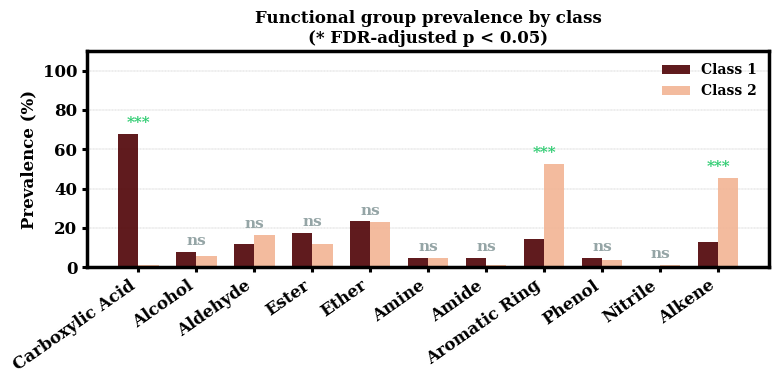

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))

x     = np.arange(len(FG_COLS))
width = 0.35

bars1 = ax.bar(x - width/2, stats["prev_c1"], width,
               color=C1_COLOR, label="Class 1", alpha=0.9, zorder=2)
bars2 = ax.bar(x + width/2, stats["prev_c2"], width,
               color=C2_COLOR, label="Class 2", alpha=0.9, zorder=2)

# significance stars above the taller bar
for i, row in stats.iterrows():
    y_top = max(row["prev_c1"], row["prev_c2"]) + 2
    color = "#2ecc71" if row["sig"] else "#95a5a6"
    ax.text(x[i], y_top, row["stars"], ha="center", va="bottom",
            fontsize=11, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(FG_LABELS, rotation=35, ha="right")
ax.set_ylabel("Prevalence (%)")
ax.set_title("Functional group prevalence by class\n(* FDR-adjusted p < 0.05)")
ax.set_ylim(0, 110)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("fg_plot1_prevalence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

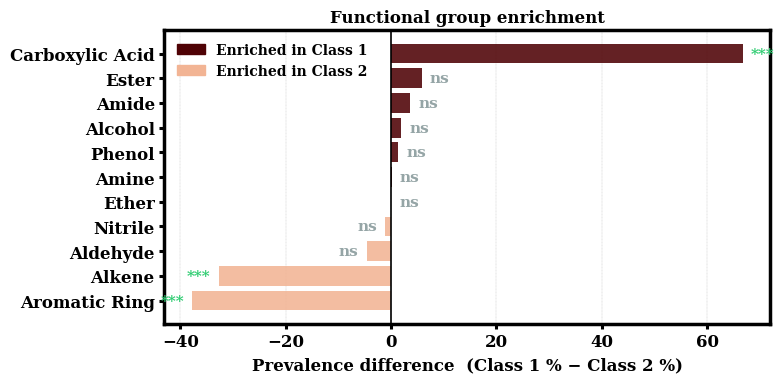

In [86]:
fig, ax = plt.subplots(figsize=(8, 4))

order  = stats.sort_values("diff")
colors = [C1_COLOR if d > 0 else C2_COLOR for d in order["diff"]]
bars   = ax.barh(order["label"], order["diff"], color=colors, alpha=0.88, zorder=2)

# annotate significance
for i, (_, row) in enumerate(order.iterrows()):
    x_pos = row["diff"] + (1.5 if row["diff"] >= 0 else -1.5)
    ha    = "left" if row["diff"] >= 0 else "right"
    color = "#2ecc71" if row["sig"] else "#95a5a6"
    ax.text(x_pos, i, row["stars"], va="center", ha=ha,
            fontsize=11, color=color, fontweight="bold")

ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Prevalence difference  (Class 1 % − Class 2 %)")
ax.set_title("Functional group enrichment")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

c1_patch = mpatches.Patch(color=C1_COLOR, label="Enriched in Class 1")
c2_patch = mpatches.Patch(color=C2_COLOR, label="Enriched in Class 2")
ax.legend(handles=[c1_patch, c2_patch], frameon=False)

plt.tight_layout()
#plt.savefig("fg_plot2_diverging.png", dpi=300, bbox_inches="tight")
plt.show()

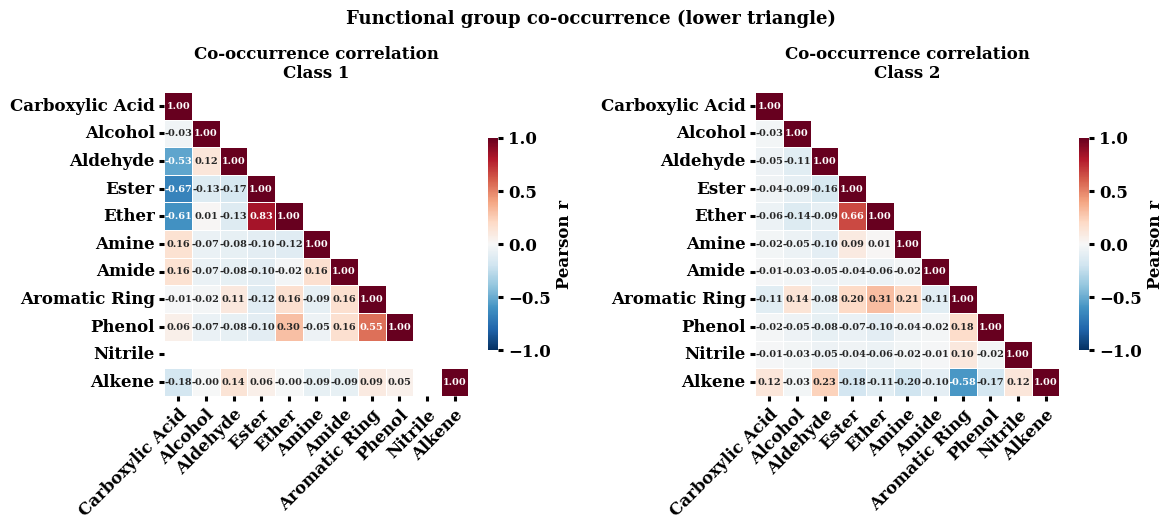

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, grp in zip(axes, GROUPS):
    sub  = ae_c.loc[ae_c["comparison_group"] == grp, FG_COLS]
    corr = sub.corr(method="pearson")
    corr.index   = FG_LABELS
    corr.columns = FG_LABELS

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle
    sns.heatmap(
        corr, ax=ax, mask=mask,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 7},
        square=True, linewidths=0.4, linecolor="white",
        cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    )
    ax.set_title(f"Co-occurrence correlation\n{GROUP_LABELS[grp]}", pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Functional group co-occurrence (lower triangle)", fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig("fg_plot3_cooccurrence.png", dpi=300, bbox_inches="tight")
plt.show()

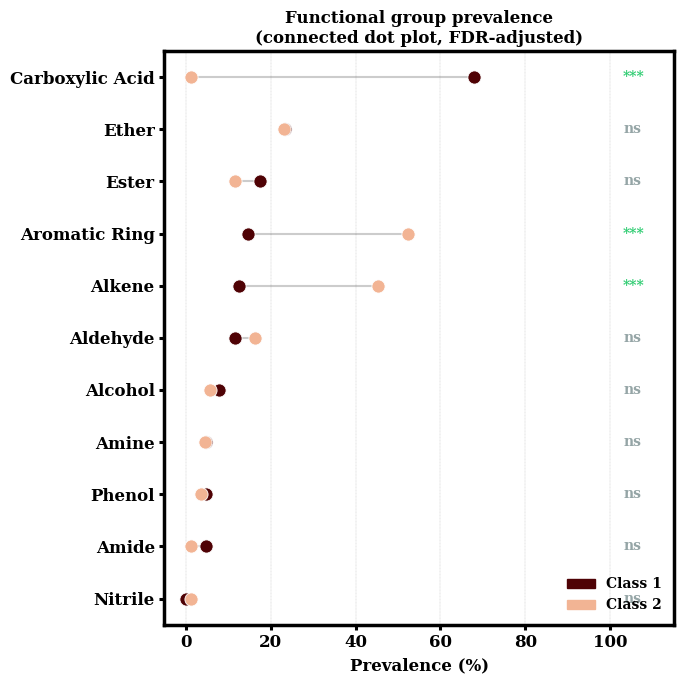

In [88]:
fig, ax = plt.subplots(figsize=(7, 7))

order = stats.sort_values("prev_c1", ascending=True).reset_index(drop=True)

for i, row in order.iterrows():
    # connecting line
    ax.hlines(i, row["prev_c1"], row["prev_c2"],
              colors="#cccccc", linewidth=1.5, zorder=1)
    # dots
    ax.scatter(row["prev_c1"], i, color=C1_COLOR, s=90, zorder=3,
               edgecolors="white", linewidth=0.6)
    ax.scatter(row["prev_c2"], i, color=C2_COLOR, s=90, zorder=3,
               edgecolors="white", linewidth=0.6)
    # stars at right margin
    color = "#2ecc71" if row["sig"] else "#95a5a6"
    ax.text(103, i, row["stars"], va="center", ha="left",
            fontsize=10, color=color, fontweight="bold")

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order["label"])
ax.set_xlabel("Prevalence (%)")
ax.set_title("Functional group prevalence\n(connected dot plot, FDR-adjusted)")
ax.set_xlim(-5, 115)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

c1_patch = mpatches.Patch(color=C1_COLOR, label="Class 1")
c2_patch = mpatches.Patch(color=C2_COLOR, label="Class 2")
ax.legend(handles=[c1_patch, c2_patch], frameon=False, loc="lower right")

plt.tight_layout()
#plt.savefig("fg_plot4_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

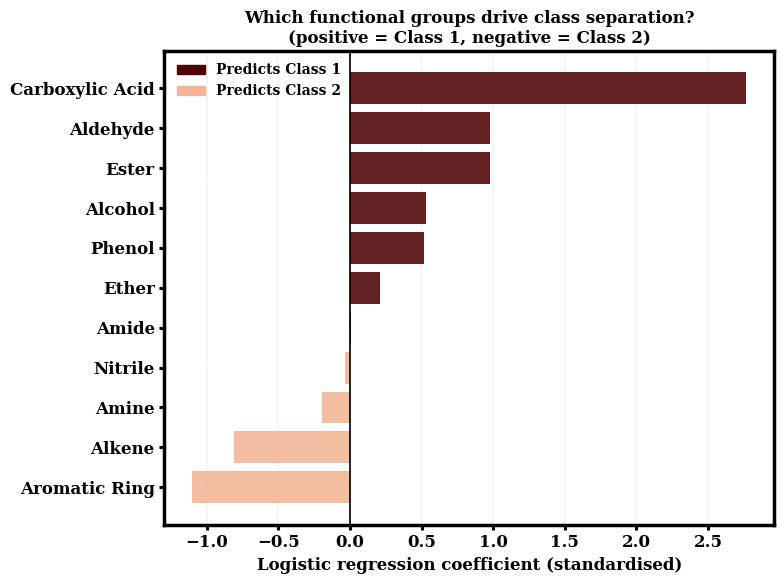

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = ae_c[FG_COLS].fillna(0).values
y = (ae_c["comparison_group"] == "class1_side").astype(int).values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X_sc, y)
coefs = pd.DataFrame({
    "label": FG_LABELS,
    "coef":  lr.coef_[0]
}).sort_values("coef")

fig, ax = plt.subplots(figsize=(8, 6))

colors = [C1_COLOR if c > 0 else C2_COLOR for c in coefs["coef"]]
ax.barh(coefs["label"], coefs["coef"], color=colors, alpha=0.88, zorder=2)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Logistic regression coefficient (standardised)")
ax.set_title("Which functional groups drive class separation?\n(positive = Class 1, negative = Class 2)")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

c1_patch = mpatches.Patch(color=C1_COLOR, label="Predicts Class 1")
c2_patch = mpatches.Patch(color=C2_COLOR, label="Predicts Class 2")
ax.legend(handles=[c1_patch, c2_patch], frameon=False)

plt.tight_layout()
#plt.savefig("fg_plot5_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

In [90]:
odors = pd.read_csv("/home/izirdeli/Documents.cglab/DownStreamAnalysis/01.Data/metadata/inchi_smiles_odors.csv")
odors

,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,CC1=C(C(=CC=C1)C)C,NaN
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"balsamic, winey, oily, solvent, fermented, swe..."
...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"meaty, fruity, sulfurous"
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orangeflower, powdery, honey, sweet, floral, o..."
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green"
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN


In [91]:
from collections import Counter

merged = ae_c[["SMILES", "comparison_group"]].merge(
    odors[["SMILES", "Odors"]],
    on="SMILES",
    how="inner"
).dropna(subset=["Odors"])

print(f"Matched: {len(merged)} molecules with odor tags")
print(merged["comparison_group"].value_counts())

merged["odor_list"] = merged["Odors"].str.split(",").apply(
    lambda tags: [t.strip().lower() for t in tags] if isinstance(tags, list) else []
)
exploded = merged.explode("odor_list").rename(columns={"odor_list": "odor_tag"})
exploded = exploded[exploded["odor_tag"].str.len() > 0]

print(f"\nUnique odor tags: {exploded['odor_tag'].nunique()}")
print(exploded["odor_tag"].value_counts().head(15))

Matched: 133 molecules with odor tags
comparison_group
class2_side    67
class1_side    66
Name: count, dtype: int64

Unique odor tags: 131
odor_tag
sweet       59
fruity      46
green       39
floral      36
fatty       35
waxy        31
fresh       19
woody       17
herbal      16
cheesy      16
sour        14
creamy      13
balsamic    13
rose        12
spicy       12
Name: count, dtype: int64


In [92]:
# For each odor tag T and cluster C:
#   observed = count of molecules with tag T in cluster C
#   null     = shuffle class labels 9,999 times → distribution of counts
#   p        = fraction of permutations ≥ observed (one-tailed, over-representation)

N_PERM   = 9_999
MIN_COUNT = 3      # ignore tags with fewer than MIN_COUNT total occurrences
rng      = np.random.default_rng(42)

# molecule-level: one row per molecule, set of its odor tags
mol_tags = (
    merged[["SMILES", "comparison_group", "odor_list"]]
    .drop_duplicates("SMILES")
    .set_index("SMILES")
)

groups_array = mol_tags["comparison_group"].values   # for shuffling
tag_matrix   = mol_tags["odor_list"].values          # list of tags per molecule

all_tags = [t for tags in tag_matrix for t in tags]
tag_counts = Counter(all_tags)
valid_tags = [t for t, c in tag_counts.items() if c >= MIN_COUNT]
print(f"\nTags passing min count ({MIN_COUNT}): {len(valid_tags)}")

def observed_count(tag, group_labels, target_group):
    return sum(
        tag in tags
        for tags, grp in zip(tag_matrix, group_labels)
        if grp == target_group
    )

results = []
for tag in valid_tags:
    for target in ["class1_side", "class2_side"]:
        obs = observed_count(tag, groups_array, target)

        # permutation null
        null_counts = np.zeros(N_PERM, dtype=int)
        for i in range(N_PERM):
            shuffled = rng.permutation(groups_array)
            null_counts[i] = observed_count(tag, shuffled, target)

        p_val = (null_counts >= obs).mean()

        n_target  = (groups_array == target).sum()
        prev      = obs / n_target * 100

        results.append({
            "odor_tag":   tag,
            "group":      target,
            "n_molecules": n_target,
            "observed":   obs,
            "prevalence": prev,
            "null_mean":  null_counts.mean(),
            "null_std":   null_counts.std(),
            "p_value":    p_val,
            "enrichment": obs / (null_counts.mean() + 1e-9),  # fold over null mean
        })

perm_df = pd.DataFrame(results)

# keep significant hits (p < 0.05)
sig_df = perm_df[perm_df["p_value"] < 0.05].copy()
print(f"\nSignificant enrichments: {len(sig_df)}")
print(sig_df.sort_values("p_value").to_string(index=False))


Tags passing min count (3): 83

Significant enrichments: 26
   odor_tag       group  n_molecules  observed  prevalence  null_mean  null_std  p_value  enrichment
       waxy class1_side           66        27   40.909091  15.353535  2.456243 0.000000    1.758553
       sour class1_side           66        14   21.212121   6.937994  1.790049 0.000100    2.017874
      spicy class2_side           67        12   17.910448   6.051105  1.658060 0.000100    1.983109
      woody class2_side           67        16   23.880597   8.571857  1.933491 0.000200    1.866573
      fatty class1_side           66        26   39.393939  17.402140  2.574774 0.000300    1.494069
      dairy class1_side           66        11   16.666667   5.483948  1.601866 0.000300    2.005854
    coconut class1_side           66        10   15.151515   4.937894  1.523639 0.000400    2.025155
   odorless class1_side           66        10   15.151515   4.960796  1.532155 0.000400    2.015805
     creamy class1_side       

In [93]:
sig_df

,odor_tag,group,n_molecules,observed,prevalence,null_mean,null_std,p_value,enrichment
2,buttery,class1_side,66,5,7.575758,2.483948,1.117695,0.028603,2.012924
6,creamy,class1_side,66,12,18.181818,6.427243,1.716618,0.000800,1.867053
8,sour,class1_side,66,14,21.212121,6.937994,1.790049,0.000100,2.017874
10,odorless,class1_side,66,10,15.151515,4.960796,1.532155,0.000400,2.015805
13,sulfurous,class2_side,67,7,10.447761,4.043704,1.385273,0.034803,1.731086
15,herbal,class2_side,67,14,20.895522,8.077308,1.883688,0.001400,1.733251
27,plum,class2_side,67,6,8.955224,3.025003,1.207113,0.014001,1.983469
31,floral,class2_side,67,23,34.328358,18.140314,2.598324,0.046205,1.267894
37,woody,class2_side,67,16,23.880597,8.571857,1.933491,0.000200,1.866573
41,minty,class2_side,67,6,8.955224,3.027403,1.195990,0.015502,1.981897


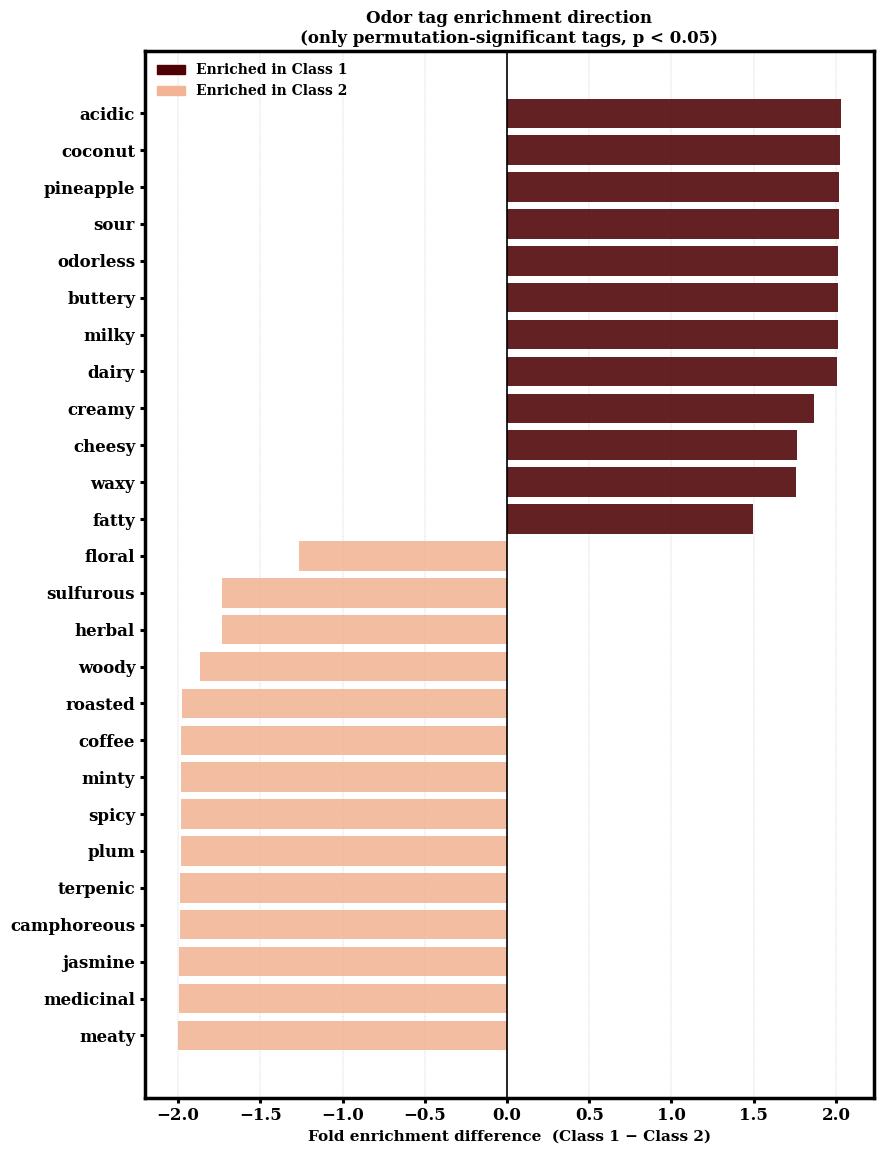

In [ ]:
## enrichment = fold change ##

# Pivot: one row per tag, columns = enrichment per class
pivot = sig_df.pivot(index="odor_tag", columns="group", values="enrichment").fillna(0)
pivot["diff"] = pivot.get("class1_side", 0) - pivot.get("class2_side", 0)
pivot = pivot.sort_values("diff")

fig, ax = plt.subplots(figsize=(9, max(5, len(pivot) * 0.45)))

colors = [C1_COLOR if d > 0 else C2_COLOR for d in pivot["diff"]]
ax.barh(pivot.index, pivot["diff"], color=colors, alpha=0.88, zorder=2)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Fold enrichment difference  (Class 1 − Class 2)", fontsize=11)
ax.set_title("Odor tag enrichment direction\n(only permutation-significant tags, p < 0.05)", fontsize=12)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

c1_patch = mpatches.Patch(color=C1_COLOR, label="Enriched in Class 1")
c2_patch = mpatches.Patch(color=C2_COLOR, label="Enriched in Class 2")
ax.legend(handles=[c1_patch, c2_patch], frameon=False)

plt.tight_layout()
#plt.savefig("odor_plot2_diverging.png", dpi=300, bbox_inches="tight")
plt.show()

In [96]:
pivot

group,class1_side,class2_side,diff
odor_tag,,,
meaty,0.000000,2.000734,-2.000734
medicinal,0.000000,1.993103,-1.993103
jasmine,0.000000,1.992785,-1.992785
camphoreous,0.000000,1.987004,-1.987004
terpenic,0.000000,1.987004,-1.987004
plum,0.000000,1.983469,-1.983469
spicy,0.000000,1.983109,-1.983109
minty,0.000000,1.981897,-1.981897
coffee,0.000000,1.980784,-1.980784


In [40]:
pivot

group,class1_side,class2_side,diff
odor_tag,,,
meaty,1.000000,2.000734,-1.000734
medicinal,1.000000,1.993103,-0.993103
jasmine,1.000000,1.992785,-0.992785
camphoreous,1.000000,1.987004,-0.987004
terpenic,1.000000,1.987004,-0.987004
plum,1.000000,1.983469,-0.983469
spicy,1.000000,1.983109,-0.983109
minty,1.000000,1.981897,-0.981897
coffee,1.000000,1.980784,-0.980784


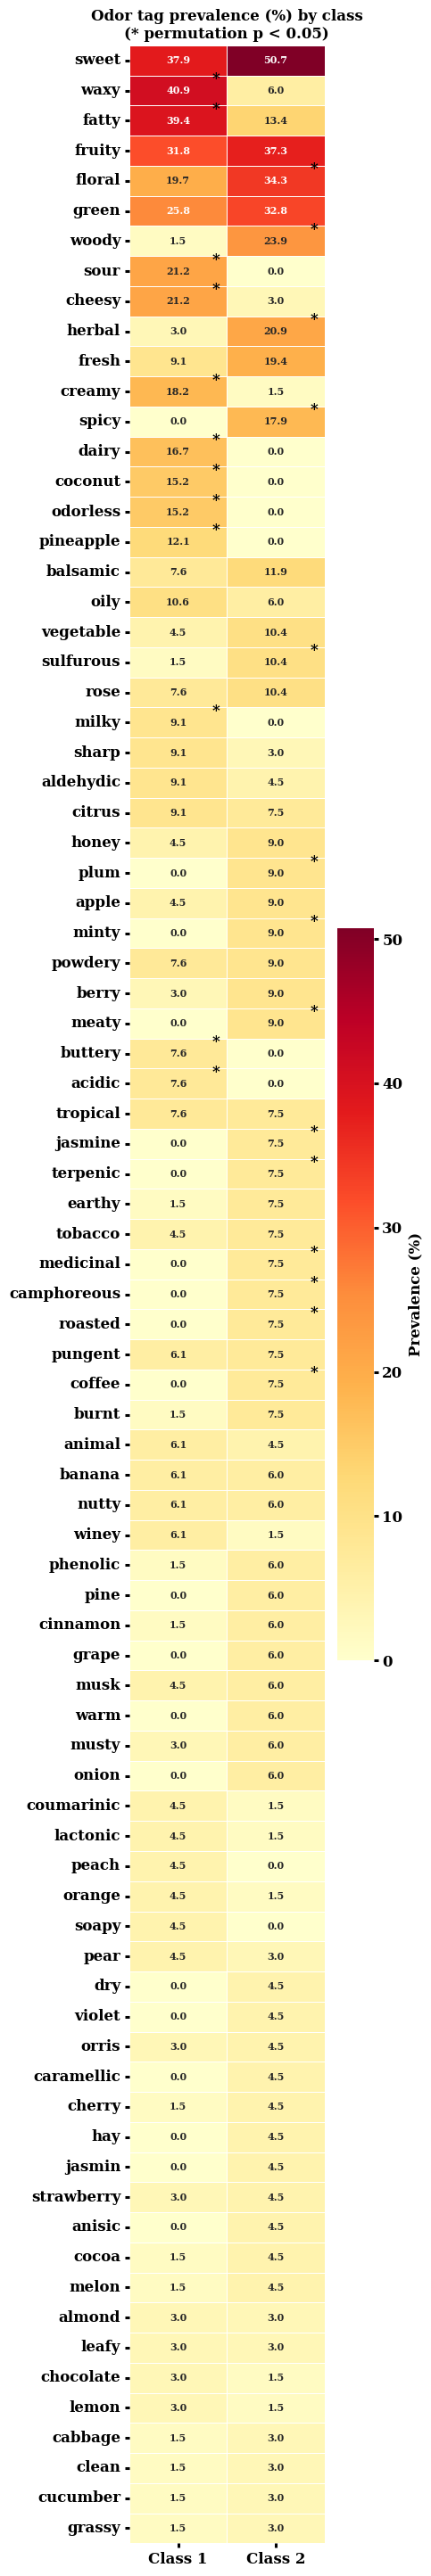

In [41]:
heat_data = (
    perm_df.pivot(index="odor_tag", columns="group", values="prevalence")
    .loc[valid_tags]
    .fillna(0)
)
heat_data.columns = ["Class 1", "Class 2"]
heat_data["max_prev"] = heat_data.max(axis=1)
heat_data = heat_data.sort_values("max_prev", ascending=False).drop(columns="max_prev")

# mark significant cells
sig_mask = perm_df.pivot(index="odor_tag", columns="group", values="p_value").reindex(heat_data.index)
sig_mask.columns = ["Class 1", "Class 2"]

fig, ax = plt.subplots(figsize=(5, max(6, len(heat_data) * 0.35)))

import seaborn as sns
sns.heatmap(
    heat_data, ax=ax,
    cmap="YlOrRd", annot=True, fmt=".1f",
    annot_kws={"size": 8}, linewidths=0.4,
    cbar_kws={"label": "Prevalence (%)"},
)

# overlay asterisks for significant cells
for i, tag in enumerate(heat_data.index):
    for j, grp in enumerate(["Class 1", "Class 2"]):
        grp_key = "class1_side" if grp == "Class 1" else "class2_side"
        p_row = perm_df[(perm_df["odor_tag"] == tag) & (perm_df["group"] == grp_key)]
        if not p_row.empty and p_row.iloc[0]["p_value"] < 0.05:
            ax.text(j + 0.85, i + 0.25, "*", color="black", fontsize=12, fontweight="bold")

ax.set_title("Odor tag prevalence (%) by class\n(* permutation p < 0.05)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
#plt.savefig("odor_plot3_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## CLASS I (a+e) VS COMBINATORIAL CODING (b)

In [42]:
ae_b = pattern_analysis_df[
    pattern_analysis_df["pattern"].isin(["100", "110", "111"])
].copy()

ae_b["comparison_group"] = ae_b["pattern"].apply(
    lambda p: "class1_side" if p in ["100", "110"] else "combinatorial"
)

ae_b["comparison_group"].value_counts()

comparison_group
class1_side      103
combinatorial     27
Name: count, dtype: int64

In [43]:
desc_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]

summary_table = (
    ae_b.groupby("comparison_group")[desc_cols]
    .agg(["count", "median", "mean"])
)

summary_table

logP                    TPSA                      MW  \
                 count  median      mean count median       mean count   
comparison_group                                                         
class1_side        103  1.8822  1.732603   103  37.30  48.272524   103   
combinatorial       27  3.2422  2.630427    27  34.14  60.070741    27   

                                        HBD                    HBA         \
                   median        mean count median      mean count median   
comparison_group                                                            
class1_side       158.241  168.014117   103    1.0  1.223301   103    1.0   
combinatorial     264.409  278.403704    27    1.0  1.407407    27    2.0   

                            
                      mean  
comparison_group            
class1_side       1.834951  
combinatorial     3.037037

In [44]:
from scipy.stats import mannwhitneyu

def mw_test(
    df,
    value_col,
    alternative="two-sided",
    group_col="comparison_group",
    group_labels=("class1_side", "combinatorial"),
):
    x = df.loc[df[group_col] == group_labels[0], value_col].dropna().values
    y = df.loc[df[group_col] == group_labels[1], value_col].dropna().values

    if len(x) == 0 or len(y) == 0:
        raise ValueError(f"One or both groups are empty for '{value_col}'")

    stat, p = mannwhitneyu(x, y, alternative=alternative)

    n = len(x) * len(y)
    r = 1 - (2 * stat) / n  # rank-biserial correlation [-1, 1]

    return {
        "descriptor": value_col,
        "n_class1": len(x),
        "n_combinatorial": len(y),
        "median_class1": np.median(x),
        "median_combinatorial": np.median(y),
        "U_stat": stat,
        "p_value": p,
        "effect_size_r": r,
    }


tests = [
    ("logP", "less"),
    ("TPSA", "greater"),
    ("HBD",  "greater"),
    ("HBA",  "greater"),
    ("MW",   "two-sided"),
]

descriptor_stats = pd.DataFrame([
    mw_test(ae_b, col, alternative=alt) for col, alt in tests
])

descriptor_stats

,descriptor,n_class1,n_combinatorial,median_class1,median_combinatorial,U_stat,p_value,effect_size_r
0,logP,103,27,1.8822,3.2422,858.0,1.131551e-03,0.382956
1,TPSA,103,27,37.3000,34.1400,1587.0,1.242975e-01,-0.141316
2,HBD,103,27,1.0000,1.0000,1579.0,1.285297e-01,-0.135563
3,HBA,103,27,1.0000,2.0000,889.0,9.990189e-01,0.360662
4,MW,103,27,158.2410,264.4090,416.0,2.267330e-08,0.700827


In [45]:
C1_COLOR = "#4f0205"   
COMBINATORIAL_COLOR = "#344B33"   
SIG_COLOR = "#2ecc71"
NS_COLOR  = "#95a5a6"

descriptors = ["logP", "TPSA", "HBD", "HBA", "MW"]

tests = [
    ("logP", "less"),
    ("TPSA", "greater"),
    ("HBD",  "greater"),
    ("HBA",  "greater"),
    ("MW",   "two-sided"),
]

def mw_test(df, value_col, alternative="two-sided",
            group_col="comparison_group",
            group_labels=("class1_side", "combinatorial")):
    x = df.loc[df[group_col] == group_labels[0], value_col].dropna().values
    y = df.loc[df[group_col] == group_labels[1], value_col].dropna().values
    if len(x) == 0 or len(y) == 0:
        raise ValueError(f"One or both groups are empty for '{value_col}'")
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    r = 1 - (2 * stat) / (len(x) * len(y))
    return {"descriptor": value_col, "n_class1": len(x), "n_combinatorial": len(y),
            "median_class1": np.median(x), "median_combinatorial": np.median(y),
            "U_stat": stat, "p_value": p, "effect_size_r": r}

stats_df = pd.DataFrame([mw_test(ae_b, col, alternative=alt) for col, alt in tests])
stats_df

,descriptor,n_class1,n_combinatorial,median_class1,median_combinatorial,U_stat,p_value,effect_size_r
0,logP,103,27,1.8822,3.2422,858.0,1.131551e-03,0.382956
1,TPSA,103,27,37.3000,34.1400,1587.0,1.242975e-01,-0.141316
2,HBD,103,27,1.0000,1.0000,1579.0,1.285297e-01,-0.135563
3,HBA,103,27,1.0000,2.0000,889.0,9.990189e-01,0.360662
4,MW,103,27,158.2410,264.4090,416.0,2.267330e-08,0.700827


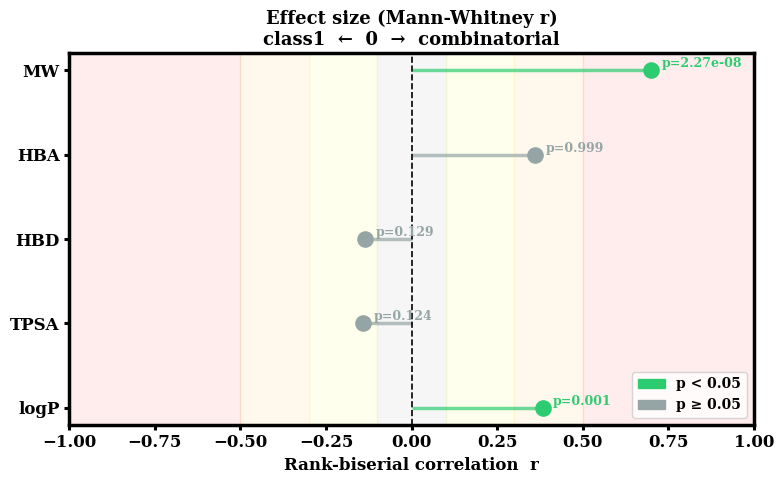

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, row in stats_df.iterrows():
    sig   = row["p_value"] < 0.05
    color = SIG_COLOR if sig else NS_COLOR
    r     = row["effect_size_r"]

    # simple bootstrap CI for r (via U)
    ax.scatter(r, i, color=color, s=120, zorder=3)
    ax.hlines(i, 0, r, colors=color, linewidth=2.5, alpha=0.7)

ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.axvspan(-0.1, 0.1, alpha=0.07, color="gray", label="Negligible (|r|<0.1)")
ax.axvspan( 0.1, 0.3, alpha=0.07, color="yellow")
ax.axvspan(-0.3,-0.1, alpha=0.07, color="yellow")
ax.axvspan( 0.3, 0.5, alpha=0.07, color="orange")
ax.axvspan(-0.5,-0.3, alpha=0.07, color="orange")
ax.axvspan( 0.5, 1.1, alpha=0.07, color="red")
ax.axvspan(-1.1,-0.5, alpha=0.07, color="red")

ax.set_yticks(range(len(stats_df)))
ax.set_yticklabels(stats_df["descriptor"], fontsize=12)
ax.set_xlabel("Rank-biserial correlation  r", fontsize=12)
ax.set_title("Effect size (Mann-Whitney r)\nclass1  ←  0  →  combinatorial", fontsize=13)
ax.set_xlim(-1, 1)

# annotate p-values
for i, row in stats_df.iterrows():
    p_label = f"p={row['p_value']:.2e}" if row['p_value'] < 0.001 else f"p={row['p_value']:.3f}"
    ax.text(row["effect_size_r"] + 0.03, i, p_label, va="bottom", fontsize=9,
            color=SIG_COLOR if row["p_value"] < 0.05 else NS_COLOR)

sig_patch = mpatches.Patch(color=SIG_COLOR, label="p < 0.05")
ns_patch  = mpatches.Patch(color=NS_COLOR,  label="p ≥ 0.05")
ax.legend(handles=[sig_patch, ns_patch], loc="lower right")
plt.tight_layout()
#plt.savefig("plot1_forest.png", dpi=150)
plt.show()

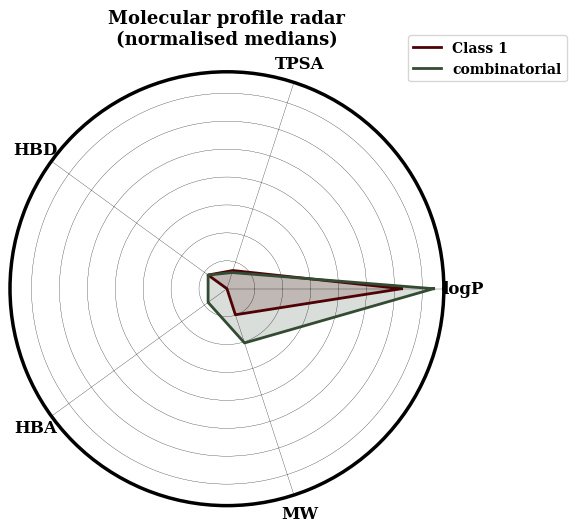

In [47]:
from matplotlib.patches import FancyArrowPatch

categories = descriptors
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Normalise medians to [0,1] per descriptor for comparability
norm_vals = {}
for col in descriptors:
    all_vals = ae_b[col].dropna()
    vmin, vmax = all_vals.min(), all_vals.max()
    for grp in ["class1_side", "combinatorial"]:
        med = ae_b.loc[ae_b["comparison_group"] == grp, col].median()
        norm_vals[(grp, col)] = (med - vmin) / (vmax - vmin) if vmax > vmin else 0.5

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for grp, color, label in [("class1_side", C1_COLOR, "Class 1"),
                           ("combinatorial", COMBINATORIAL_COLOR, "combinatorial")]:
    values = [norm_vals[(grp, c)] for c in categories] 
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=label)
    ax.fill(angles, values, color=color, alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels([])
ax.set_title("Molecular profile radar\n(normalised medians)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
#plt.savefig("plot3_radar.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

/tmp/ipykernel_3805385/494218152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ae_b, x="comparison_group", y=col,
/tmp/ipykernel_3805385/494218152.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["class1", "combinatorial"], fontsize=9)
/tmp/ipykernel_3805385/494218152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ae_b, x="comparison_group", y=col,
/tmp/ipykernel_3805385/494218152.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["class1", "combinatorial"]

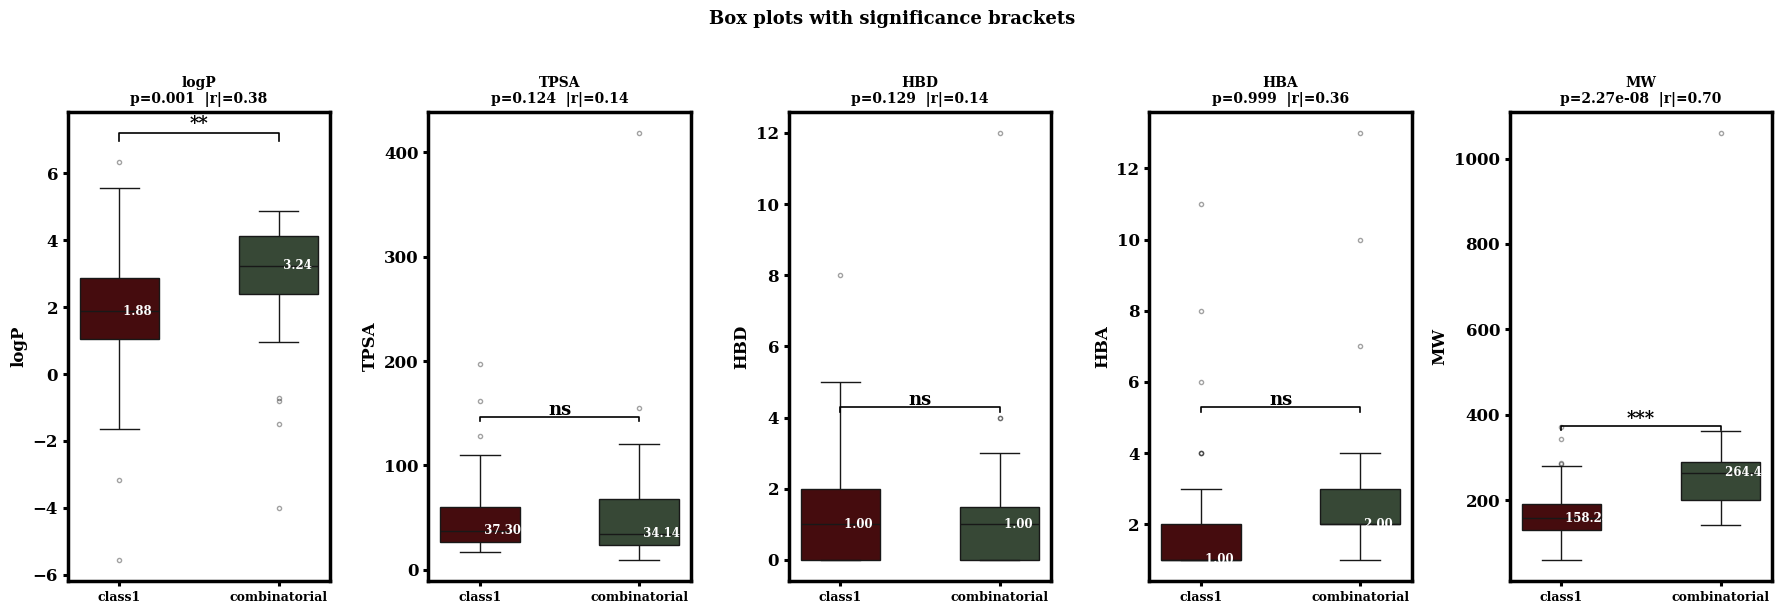

In [48]:
palette = {
    "class1_side": "#4f0205",
    "combinatorial": "#344B33",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for ax, (col, alt) in zip(axes, tests):
    row = stats_df[stats_df["descriptor"] == col].iloc[0]

    sns.boxplot(data=ae_b, x="comparison_group", y=col,
                palette=palette, ax=ax, width=0.5,
                flierprops=dict(marker="o", markersize=3, alpha=0.4))

    # median labels
    for j, grp in enumerate(["class1_side", "combinatorial"]):
        med = ae_b.loc[ae_b["comparison_group"] == grp, col].median()
        ax.text(j, med, f" {med:.2f}", va="center", fontsize=8.5,
                color="white", fontweight="bold")

    # significance bracket
    y_max   = ae_b[col].quantile(0.95)
    y_range = ae_b[col].quantile(0.95) - ae_b[col].quantile(0.05)
    y_top   = y_max + y_range * 0.39
    p       = row["p_value"]
    stars   = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ax.plot([0, 0, 1, 1], [y_top, y_top + y_range*0.04, y_top + y_range*0.04, y_top],
            lw=1.2, color="black")
    ax.text(0.5, y_top + y_range * 0.06, stars, ha="center", fontsize=13)

    p_label = f"p={p:.2e}" if p < 0.001 else f"p={p:.3f}"
    ax.set_title(f"{col}\n{p_label}  |r|={abs(row['effect_size_r']):.2f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["class1", "combinatorial"], fontsize=9)

plt.suptitle("Box plots with significance brackets", fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig("plot4_boxplots.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [49]:
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# config 
FG_COLS = [
    "carboxylic_acid", "alcohol", "aldehyde", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol", "nitrile", "alkene"
]
FG_LABELS = [c.replace("_", " ").title() for c in FG_COLS]

C1_COLOR = "#4f0205"   
COMBINATORIAL_COLOR = "#344B33"   
PALETTE   = {"class1_side": C1_COLOR, "combinatorial": COMBINATORIAL_COLOR}

GROUPS    = ["class1_side", "combinatorial"]
GROUP_LABELS = {"class1_side": "Class 1", "combinatorial": "Combinatorial"}

# statistical tests per functional group 
def fg_stats(df):
    rows = []
    for col in FG_COLS:
        ct = pd.crosstab(df["comparison_group"], df[col])
        # ensure both 0/1 columns exist
        for v in [0, 1]:
            if v not in ct.columns:
                ct[v] = 0
        ct = ct[[0, 1]]

        # fisher exact if small counts, else chi2
        if ct.values.min() < 5:
            odds, p = fisher_exact(ct.values)
        else:
            chi2, p, _, _ = chi2_contingency(ct.values)

        prev = {}
        for grp in GROUPS:
            sub = df.loc[df["comparison_group"] == grp, col]
            prev[grp] = sub.mean() * 100   # percentage

        rows.append({
            "fg": col,
            "label": col.replace("_", " ").title(),
            "prev_c1": prev["class1_side"],
            "prev_combinatorial": prev["combinatorial"],
            "diff":    prev["class1_side"] - prev["combinatorial"],
            "p_raw":   p,
        })

    res = pd.DataFrame(rows)
    # FDR correction (Benjamini-Hochberg)
    _, p_adj, _, _ = multipletests(res["p_raw"], method="fdr_bh")
    res["p_adj"] = p_adj
    res["sig"]   = res["p_adj"] < 0.05
    res["stars"]  = res["p_adj"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    )
    return res

stats = fg_stats(ae_b)
print(stats[["label", "prev_c1", "prev_combinatorial", "p_raw", "p_adj", "stars"]].to_string(index=False))

          label   prev_c1  prev_combinatorial        p_raw        p_adj stars
Carboxylic Acid 67.961165            3.703704 4.769159e-10 5.246075e-09   ***
        Alcohol  7.766990           37.037037 3.101385e-04 1.137175e-03    **
       Aldehyde 11.650485            0.000000 7.081319e-02 1.557890e-01    ns
          Ester 17.475728           22.222222 7.739577e-01 8.513534e-01    ns
          Ether 23.300971           40.740741 1.153033e-01 1.811908e-01    ns
          Amine  4.854369           14.814815 8.859330e-02 1.624211e-01    ns
          Amide  4.854369            7.407407 6.345459e-01 7.755561e-01    ns
  Aromatic Ring 14.563107           40.740741 5.839712e-03 1.605921e-02     *
         Phenol  4.854369           11.111111 3.616226e-01 4.972310e-01    ns
        Nitrile  0.000000            0.000000 1.000000e+00 1.000000e+00    ns
         Alkene 12.621359           51.851852 2.593877e-05 1.426632e-04   ***


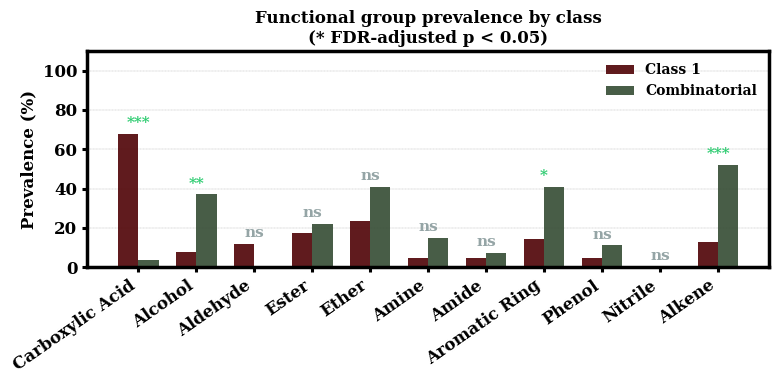

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))

x     = np.arange(len(FG_COLS))
width = 0.35

bars1 = ax.bar(x - width/2, stats["prev_c1"], width,
               color=C1_COLOR, label="Class 1", alpha=0.9, zorder=2)
bars2 = ax.bar(x + width/2, stats["prev_combinatorial"], width,
               color=COMBINATORIAL_COLOR, label="Combinatorial", alpha=0.9, zorder=2)

# significance stars above the taller bar
for i, row in stats.iterrows():
    y_top = max(row["prev_c1"], row["prev_combinatorial"]) + 2
    color = "#2ecc71" if row["sig"] else "#95a5a6"
    ax.text(x[i], y_top, row["stars"], ha="center", va="bottom",
            fontsize=11, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(FG_LABELS, rotation=35, ha="right")
ax.set_ylabel("Prevalence (%)")
ax.set_title("Functional group prevalence by class\n(* FDR-adjusted p < 0.05)")
ax.set_ylim(0, 110)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("fg_plot1_prevalence_bar.png", dpi=300, bbox_inches="tight")
plt.show()

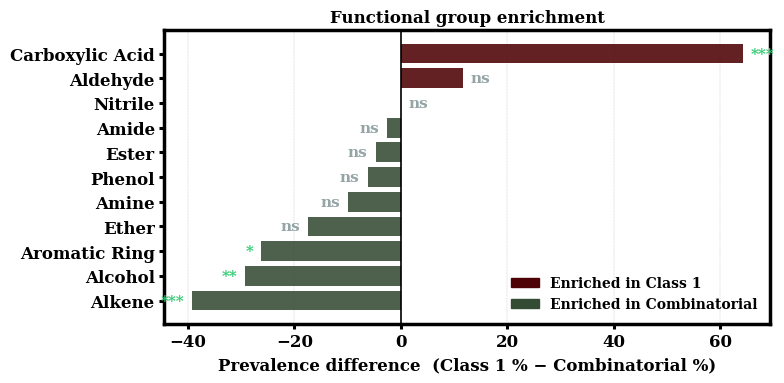

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))

order  = stats.sort_values("diff")
colors = [C1_COLOR if d > 0 else COMBINATORIAL_COLOR for d in order["diff"]]
bars   = ax.barh(order["label"], order["diff"], color=colors, alpha=0.88, zorder=2)

# annotate significance
for i, (_, row) in enumerate(order.iterrows()):
    x_pos = row["diff"] + (1.5 if row["diff"] >= 0 else -1.5)
    ha    = "left" if row["diff"] >= 0 else "right"
    color = "#2ecc71" if row["sig"] else "#95a5a6"
    ax.text(x_pos, i, row["stars"], va="center", ha=ha,
            fontsize=11, color=color, fontweight="bold")

ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Prevalence difference  (Class 1 % − Combinatorial %)")
ax.set_title("Functional group enrichment")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

c1_patch = mpatches.Patch(color=C1_COLOR, label="Enriched in Class 1")
c2_patch = mpatches.Patch(color=COMBINATORIAL_COLOR, label="Enriched in Combinatorial")
ax.legend(handles=[c1_patch, c2_patch], frameon=False)

plt.tight_layout()
#plt.savefig("fg_plot2_diverging.png", dpi=300, bbox_inches="tight")
plt.show()

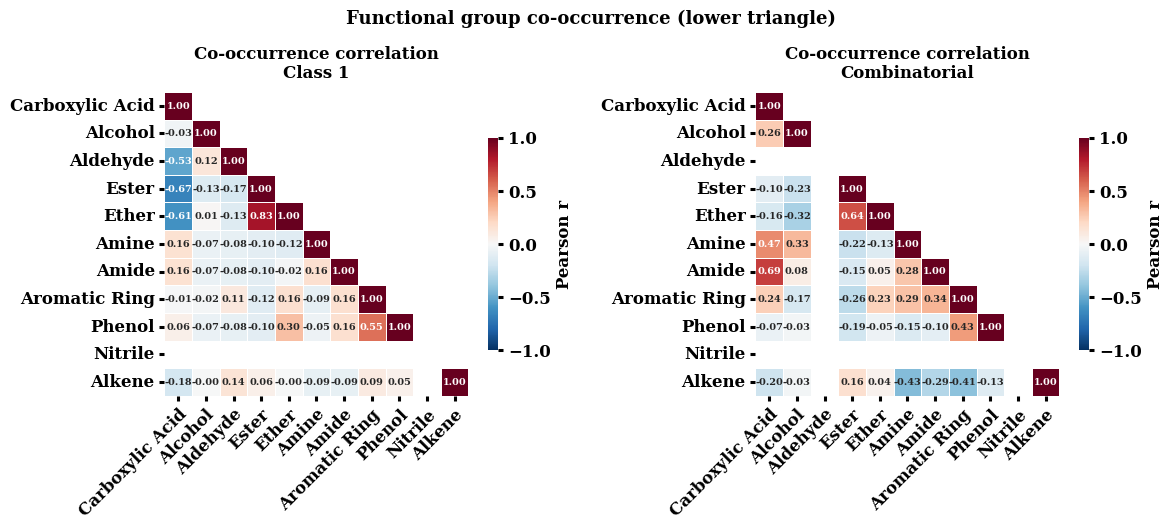

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, grp in zip(axes, GROUPS):
    sub  = ae_b.loc[ae_b["comparison_group"] == grp, FG_COLS]
    corr = sub.corr(method="pearson")
    corr.index   = FG_LABELS
    corr.columns = FG_LABELS

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle
    sns.heatmap(
        corr, ax=ax, mask=mask,
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 7},
        square=True, linewidths=0.4, linecolor="white",
        cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    )
    ax.set_title(f"Co-occurrence correlation\n{GROUP_LABELS[grp]}", pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Functional group co-occurrence (lower triangle)", fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig("fg_plot3_cooccurrence.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
from collections import Counter

merged = ae_b[["SMILES", "comparison_group"]].merge(
    odors[["SMILES", "Odors"]],
    on="SMILES",
    how="inner"
).dropna(subset=["Odors"])

print(f"Matched: {len(merged)} molecules with odor tags")
print(merged["comparison_group"].value_counts())

merged["odor_list"] = merged["Odors"].str.split(",").apply(
    lambda tags: [t.strip().lower() for t in tags] if isinstance(tags, list) else []
)
exploded = merged.explode("odor_list").rename(columns={"odor_list": "odor_tag"})
exploded = exploded[exploded["odor_tag"].str.len() > 0]

print(f"\nUnique odor tags: {exploded['odor_tag'].nunique()}")
print(exploded["odor_tag"].value_counts().head(15))

Matched: 75 molecules with odor tags
comparison_group
class1_side      66
combinatorial     9
Name: count, dtype: int64

Unique odor tags: 91
odor_tag
sweet        33
waxy         28
fatty        26
fruity       24
floral       19
green        18
cheesy       14
sour         14
creamy       13
dairy        11
odorless     10
coconut      10
pineapple     8
citrus        8
oily          7
Name: count, dtype: int64


In [57]:
exploded

,SMILES,comparison_group,Odors,odor_tag
0,C(C(=O)C(=O)O)O,class1_side,"radish, cabbage, buttery, burnt, creamy, sour",radish
0,C(C(=O)C(=O)O)O,class1_side,"radish, cabbage, buttery, burnt, creamy, sour",cabbage
0,C(C(=O)C(=O)O)O,class1_side,"radish, cabbage, buttery, burnt, creamy, sour",buttery
0,C(C(=O)C(=O)O)O,class1_side,"radish, cabbage, buttery, burnt, creamy, sour",burnt
0,C(C(=O)C(=O)O)O,class1_side,"radish, cabbage, buttery, burnt, creamy, sour",creamy
...,...,...,...,...
117,C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)C,combinatorial,"citrus, sweet, grapefruit, woody, orange",orange
119,C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C,combinatorial,"minty, cooling, mentholic, mint",minty
119,C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C,combinatorial,"minty, cooling, mentholic, mint",cooling
119,C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C,combinatorial,"minty, cooling, mentholic, mint",mentholic


In [55]:
# For each odor tag T and cluster C:
#   observed = count of molecules with tag T in cluster C
#   null     = shuffle class labels 9,999 times → distribution of counts
#   p        = fraction of permutations ≥ observed (one-tailed, over-representation)

N_PERM   = 9_999
MIN_COUNT = 1      # ignore tags with fewer than MIN_COUNT total occurrences
rng      = np.random.default_rng(42)

# molecule-level: one row per molecule, set of its odor tags
mol_tags = (
    merged[["SMILES", "comparison_group", "odor_list"]]
    .drop_duplicates("SMILES")
    .set_index("SMILES")
)

groups_array = mol_tags["comparison_group"].values   # for shuffling
tag_matrix   = mol_tags["odor_list"].values          # list of tags per molecule

all_tags = [t for tags in tag_matrix for t in tags]
tag_counts = Counter(all_tags)
valid_tags = [t for t, c in tag_counts.items() if c >= MIN_COUNT]
print(f"\nTags passing min count ({MIN_COUNT}): {len(valid_tags)}")

def observed_count(tag, group_labels, target_group):
    return sum(
        tag in tags
        for tags, grp in zip(tag_matrix, group_labels)
        if grp == target_group
    )

results = []
for tag in valid_tags:
    for target in ["class1_side", "class2_side"]:
        obs = observed_count(tag, groups_array, target)

        # permutation null
        null_counts = np.zeros(N_PERM, dtype=int)
        for i in range(N_PERM):
            shuffled = rng.permutation(groups_array)
            null_counts[i] = observed_count(tag, shuffled, target)

        p_val = (null_counts >= obs).mean()

        n_target  = (groups_array == target).sum()
        prev      = obs / n_target * 100

        results.append({
            "odor_tag":   tag,
            "group":      target,
            "n_molecules": n_target,
            "observed":   obs,
            "prevalence": prev,
            "null_mean":  null_counts.mean(),
            "null_std":   null_counts.std(),
            "p_value":    p_val,
            "enrichment": obs / (null_counts.mean() + 1e-9),  # fold over null mean
        })

perm_df = pd.DataFrame(results)

# keep significant hits (p < 0.05)
sig_df = perm_df[perm_df["p_value"] < 0.05].copy()
print(f"\nSignificant enrichments: {len(sig_df)}")
print(sig_df.sort_values("p_value").to_string(index=False))


Tags passing min count (1): 91


/tmp/ipykernel_3805385/3409407207.py:46: RuntimeWarning: invalid value encountered in scalar divide
  prev      = obs / n_target * 100



Significant enrichments: 1
odor_tag       group  n_molecules  observed  prevalence  null_mean  null_std  p_value  enrichment
   fatty class1_side           66        26   39.393939  22.883488  1.347779 0.017102     1.13619


In [56]:
sig_df

,odor_tag,group,n_molecules,observed,prevalence,null_mean,null_std,p_value,enrichment
68,fatty,class1_side,66,26,39.393939,22.883488,1.347779,0.017102,1.13619
